# Land Cover Segmentation — DeepGlobe (U-Net)

Satellite image segmentation using a U-Net architecture on the DeepGlobe Land Cover Classification dataset.

- Input: RGB satellite image 2448×2448 (tiled to 256×256 patches)
- Output: 7-class land cover segmentation mask
- Classes: urban, agriculture, rangeland, forest, water, barren, unknown

### Dataset Download

In [1]:
import kaggle
import numpy as np
from PIL import Image
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import os

DATA_DIR  = Path('data/deepglobe')
TILES_DIR = DATA_DIR / 'tiles'
TILE_SIZE = 256
N_TILES   = 9  # 9×256=2304 px used, 144px border discarded
N_WORKERS = os.cpu_count()

CLASS_MAP = {
    'Urban':       (0,   255, 255),
    'Agriculture': (255, 255, 0),
    'Rangeland':   (255, 0,   255),
    'Forest':      (0,   255, 0),
    'Water':       (0,   0,   255),
    'Barren':      (255, 255, 255),
    'Unknown':     (0,   0,   0),
}
_CLASS_COLORS = np.array(list(CLASS_MAP.values()), dtype=np.uint8)  # (7,3)

# ── Download ──────────────────────────────────────────────────────────────────
if DATA_DIR.exists() and any(DATA_DIR.iterdir()):
    print(f'Dataset already present at {DATA_DIR} — skipping download.')
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(
        'balraj98/deepglobe-land-cover-classification-dataset',
        path=str(DATA_DIR), unzip=True,
    )
    print(f'Downloaded and extracted to {DATA_DIR}')

for split in ('train', 'valid', 'test'):
    p = DATA_DIR / split
    if p.exists():
        print(f'{split}: {len(list(p.glob("*_sat.jpg")))} images')

# ── Tiling ────────────────────────────────────────────────────────────────────
def _tile_one(args):
    sat_path, out_dir, tile_size, n_tiles = args
    img_id    = sat_path.stem.replace('_sat', '')
    mask_path = sat_path.parent / f'{img_id}_mask.png'

    img   = np.array(Image.open(sat_path))
    label = None
    if mask_path.exists():
        mask_rgb = np.array(Image.open(mask_path))
        label = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
        for idx, rgb in enumerate(_CLASS_COLORS):
            label[np.all(mask_rgb == rgb, axis=-1)] = idx

    out_dir = Path(out_dir)
    for r in range(n_tiles):
        for c in range(n_tiles):
            rs, cs = r * tile_size, c * tile_size
            stem = f'{img_id}_{r:02d}_{c:02d}'
            np.save(out_dir / f'{stem}_sat.npy',  img[rs:rs+tile_size, cs:cs+tile_size])
            if label is not None:
                np.save(out_dir / f'{stem}_mask.npy', label[rs:rs+tile_size, cs:cs+tile_size])

def tile_split(split: str):
    src = DATA_DIR / split
    if not src.exists():
        return

    sat_files = sorted(src.glob('*_sat.jpg'))
    out_dir   = TILES_DIR / split
    out_dir.mkdir(parents=True, exist_ok=True)

    expected = len(sat_files) * N_TILES ** 2
    existing = len(list(out_dir.glob('*_sat.npy')))
    if existing == expected:
        print(f'{split}: already tiled ({existing} tiles) — skipping')
        return

    print(f'{split}: tiling {len(sat_files)} images → {expected} tiles '
          f'({N_WORKERS} workers) ...')

    args = [(p, str(out_dir), TILE_SIZE, N_TILES) for p in sat_files]
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        ex.map(_tile_one, args)

    n_saved = len(list(out_dir.glob('*_sat.npy')))
    print(f'{split}: {n_saved} tiles saved → {out_dir}')

for split in ('train', 'valid', 'test'):
    tile_split(split)


Dataset already present at data/deepglobe — skipping download.
train: 803 images
valid: 171 images
test: 172 images
train: already tiled (65043 tiles) — skipping
valid: already tiled (13851 tiles) — skipping
test: already tiled (13932 tiles) — skipping


### Dataset — Format & Visualization

- **Images**: 2448×2448 RGB JPEG (`{id}_sat.jpg`)
- **Masks**: 2448×2448 RGB PNG (`{id}_mask.png`) — color-encoded, not class indices

| Class | R | G | B |
|---|---|---|---|
| Urban | 0 | 255 | 255 |
| Agriculture | 255 | 255 | 0 |
| Rangeland | 255 | 0 | 255 |
| Forest | 0 | 255 | 0 |
| Water | 0 | 0 | 255 |
| Barren | 255 | 255 | 255 |
| Unknown | 0 | 0 | 0 |

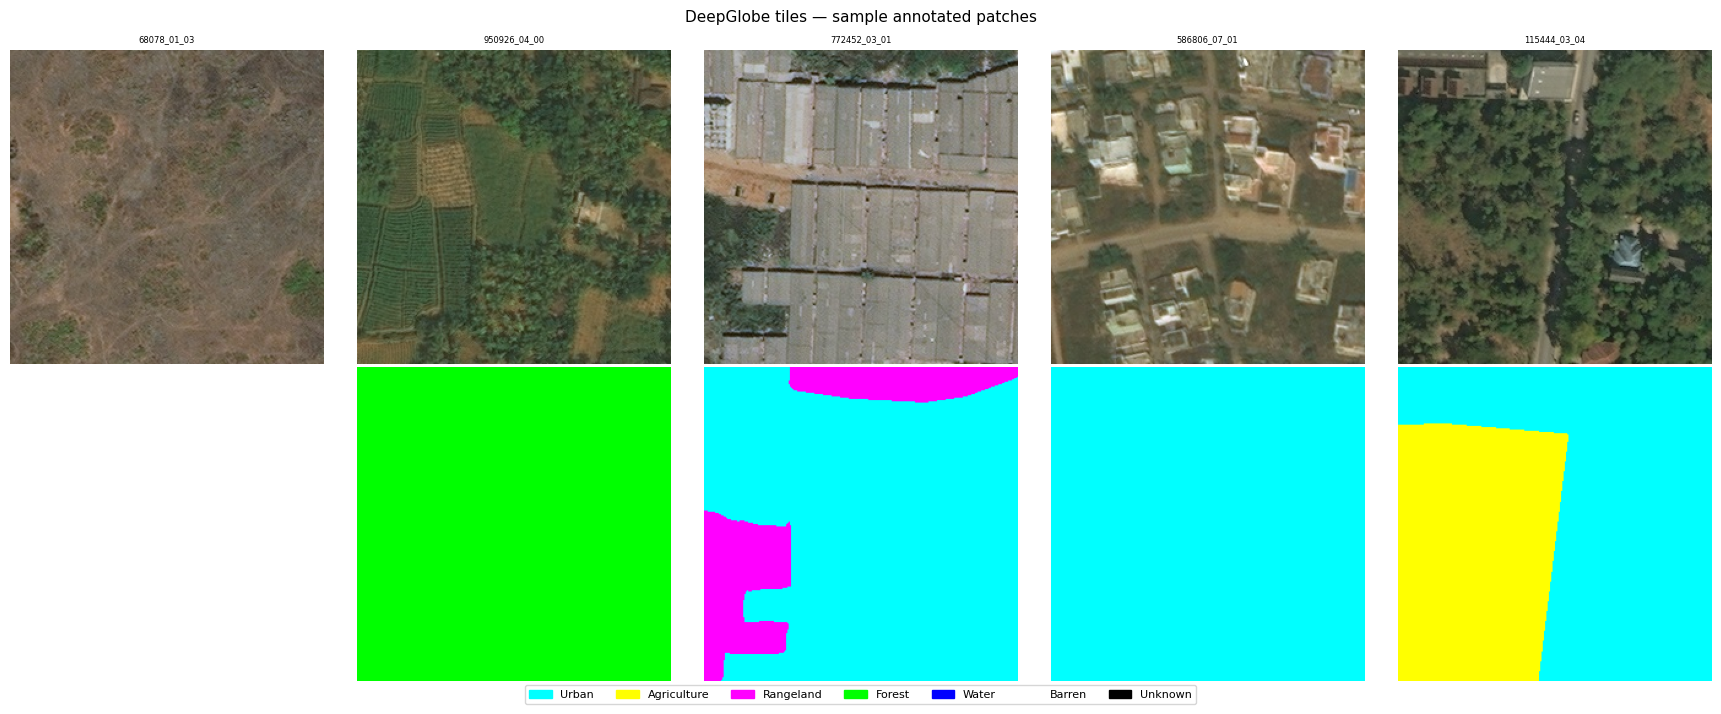

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

TILES_DIR = Path('data/deepglobe/tiles')

CLASS_MAP = {
    'Urban':       (0,   255, 255),
    'Agriculture': (255, 255, 0),
    'Rangeland':   (255, 0,   255),
    'Forest':      (0,   255, 0),
    'Water':       (0,   0,   255),
    'Barren':      (255, 255, 255),
    'Unknown':     (0,   0,   0),
}
LABEL_TO_RGB = np.array(list(CLASS_MAP.values()), dtype=np.uint8)

train_dir = TILES_DIR / 'train'
sat_files = sorted(train_dir.glob('*_sat.npy'))

N = 5
np.random.seed(42)
sample = np.random.choice(len(sat_files), N, replace=False)

fig, axes = plt.subplots(2, N, figsize=(N * 3.5, 7))

for col, idx in enumerate(sample):
    sat_path  = sat_files[idx]
    mask_path = train_dir / sat_path.name.replace('_sat.npy', '_mask.npy')

    img  = np.load(sat_path)
    mask = LABEL_TO_RGB[np.load(mask_path)]

    axes[0, col].imshow(img)
    axes[0, col].axis('off')
    axes[0, col].set_title(sat_path.stem.replace('_sat', ''), fontsize=6)

    axes[1, col].imshow(mask)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Satellite', fontsize=9)
axes[1, 0].set_ylabel('Mask', fontsize=9)

legend_patches = [
    mpatches.Patch(color=np.array(rgb) / 255, label=name)
    for name, rgb in CLASS_MAP.items()
]
fig.legend(handles=legend_patches, loc='lower center', ncol=7, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('DeepGlobe tiles — sample annotated patches', fontsize=11)
plt.tight_layout()
plt.show()


### Data Loader

`tf.data` pipeline — loads tiles from disk per batch, applies augmentation on train split only.

EfficientNetB0 includes built-in rescaling/normalization layers, so images are fed as raw uint8 (0–255).

In [3]:
import tensorflow as tf
import numpy as np
from pathlib import Path

TILES_DIR  = Path('data/deepglobe/tiles')
BATCH_SIZE = 8   # reduce to 4 if OOM
VAL_SPLIT  = 0.15
SEED       = 42

def make_datasets(batch_size: int = BATCH_SIZE, val_split: float = VAL_SPLIT):
    tiles_dir = TILES_DIR / 'train'
    sat_files = sorted(tiles_dir.glob('*_sat.npy'))

    pairs = []
    for s in sat_files:
        m = tiles_dir / s.name.replace('_sat.npy', '_mask.npy')
        if m.exists():
            pairs.append((str(s), str(m)))

    # Deterministic shuffle then split — split on image level to avoid tile leakage
    # Group by image id, split images, then flatten back to tiles
    from collections import defaultdict
    img_to_pairs = defaultdict(list)
    for s, m in pairs:
        img_id = Path(s).stem.rsplit('_', 2)[0]  # strip _{row}_{col}
        img_to_pairs[img_id].append((s, m))

    img_ids = sorted(img_to_pairs.keys())
    rng = np.random.default_rng(SEED)
    rng.shuffle(img_ids)

    n_val   = max(1, int(len(img_ids) * val_split))
    val_ids = set(img_ids[:n_val])

    train_pairs = [p for img_id in img_ids[n_val:] for p in img_to_pairs[img_id]]
    val_pairs   = [p for img_id in val_ids         for p in img_to_pairs[img_id]]

    print(f'Train: {len(img_ids) - n_val} images → {len(train_pairs)} tiles')
    print(f'Val  : {n_val} images → {len(val_pairs)} tiles')

    def _load(sat_path, mask_path):
        img   = np.load(sat_path.numpy().decode()).astype(np.uint8)
        label = np.load(mask_path.numpy().decode()).astype(np.int32)
        return img, label

    def tf_load(sat_path, mask_path):
        img, label = tf.py_function(_load, [sat_path, mask_path], [tf.uint8, tf.int32])
        img.set_shape([256, 256, 3])
        label.set_shape([256, 256])
        return img, label

    def augment_fn(img, label):
        img_f    = tf.cast(img, tf.float32)
        combined = tf.concat([img_f, tf.cast(tf.expand_dims(label, -1), tf.float32)], axis=-1)
        combined = tf.image.random_flip_left_right(combined)
        combined = tf.image.random_flip_up_down(combined)
        k        = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
        combined = tf.image.rot90(combined, k)
        img      = tf.cast(combined[:, :, :3], tf.uint8)
        label    = tf.cast(combined[:, :, 3], tf.int32)
        return img, label

    def build_ds(pairs, augment):
        sat_p, mask_p = map(list, zip(*pairs))
        ds = tf.data.Dataset.from_tensor_slices((sat_p, mask_p))
        if augment:
            ds = ds.shuffle(len(sat_p), reshuffle_each_iteration=True)
        ds = ds.map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
        if augment:
            ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
        return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return build_ds(train_pairs, augment=True), build_ds(val_pairs, augment=False)

train_ds, val_ds = make_datasets()

print(f'Train batches : {len(train_ds)}')
print(f'Val batches   : {len(val_ds)}')

for imgs, labels in train_ds.take(1):
    print(f'Image batch : {imgs.shape} {imgs.dtype}')
    print(f'Label batch : {labels.shape} {labels.dtype}')
    print(f'Label range : {labels.numpy().min()} – {labels.numpy().max()}')


I0000 00:00:1782433261.711673  557140 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Train: 6143 images → 55287 tiles
Val  : 1084 images → 9756 tiles


I0000 00:00:1782433266.795546  557140 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2091 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Train batches : 6911
Val batches   : 1220
Image batch : (8, 256, 256, 3) <dtype: 'uint8'>
Label batch : (8, 256, 256) <dtype: 'int32'>
Label range : 0 – 5


### Model — U-Net 

Standard U-Net with Skip Layers bottleneck.

In [4]:
import tensorflow as tf

N_CLASSES   = 7
INPUT_SHAPE = (256, 256, 3)

SKIP_LAYERS = [
    'block2a_expand_activation',  # 128x128
    'block3a_expand_activation',  # 64x64
    'block4a_expand_activation',  # 32x32
    'block6a_expand_activation',  # 16x16
]

def conv_block(x, filters, kernel_size=3):
    x = tf.keras.layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x

def decoder_block(x, skip, filters):
    x = tf.keras.layers.UpSampling2D(size=(2, 2), interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=INPUT_SHAPE, n_classes=N_CLASSES):
    inputs  = tf.keras.Input(shape=input_shape)
    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_tensor=inputs
    )
    skips  = [backbone.get_layer(n).output for n in SKIP_LAYERS]
    bridge = backbone.output
    x = conv_block(bridge, 256)
    x = decoder_block(x, skips[3], 256)
    x = decoder_block(x, skips[2], 128)
    x = decoder_block(x, skips[1], 64)
    x = decoder_block(x, skips[0], 32)
    x = tf.keras.layers.UpSampling2D(size=(2, 2), interpolation="bilinear")(x)
    x = conv_block(x, 16)
    outputs = tf.keras.layers.Conv2D(n_classes, 1, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

total = sum(tf.size(w).numpy() for w in model.weights)
print(f"Total params: {total:,}")


Total params: 11,297,178


In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print('GPUs available:', gpus)
print('Built with CUDA:', tf.test.is_built_with_cuda())
print('GPU will be used:', tf.test.is_gpu_available())


GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU will be used: True


I0000 00:00:1782433269.229282  557140 gpu_device.cc:2043] Created device /device:GPU:0 with 2091 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [ ]:
import tensorflow as tf

def dice_loss(y_true, y_pred, smooth=1e-6):
    """Multiclass soft Dice loss. y_true: (B,H,W) int, y_pred: (B,H,W,C) softmax."""
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), N_CLASSES)  # (B,H,W,C)
    axes = [1, 2]  # sum over spatial dims only
    intersection   = tf.reduce_sum(y_true_oh * y_pred, axis=axes)              # (B,C)
    union          = tf.reduce_sum(y_true_oh, axis=axes) + tf.reduce_sum(y_pred, axis=axes)  # (B,C)
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)          # (B,C)
    return 1.0 - tf.reduce_mean(dice_per_class)                                # scalar

def bce_dice_loss(y_true, y_pred):
    bce  = tf.keras.losses.SparseCategoricalCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


### Training

**Optimizer:** Adam — adaptive lr per parameter, standard for segmentation  
**LR:** 1e-4 — conservative; encoder starts pretrained, high lr risks destroying ImageNet features  
**Loss:** SparseCategoricalCrossentropy — takes integer labels directly, no one-hot needed  
**Epochs:** 50 — with early stopping, actual training likely shorter  
**Early stopping:** patience=10 on val loss — stops if no improvement for 10 epochs  
**LR reduction:** patience=5, factor=0.5 — halves lr on plateau before early stopping kicks in  
**Checkpoint:** saves best val loss weights only

In [ ]:
import tensorflow as tf
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
from pathlib import Path

CHECKPOINT_DIR       = Path('models/deepglobe_unet')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_AND_OVERWRITE  = True   # False → load best.keras and skip training

# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS       = 50
LR           = 1e-4
LR_FACTOR    = 0.5
LR_PATIENCE  = 5
ES_PATIENCE  = 10

config = dict(
    epochs       = EPOCHS,
    lr           = LR,
    lr_factor    = LR_FACTOR,
    lr_patience  = LR_PATIENCE,
    es_patience  = ES_PATIENCE,
    batch_size   = BATCH_SIZE,
    encoder      = 'efficientnetb0',
    input_shape  = INPUT_SHAPE,
    n_classes    = N_CLASSES,
    loss         = 'bce_dice',
    optimizer    = 'adam',
    augmentation = 'hflip+vflip+rot90',
    tiling       = f'{N_TILES}x{N_TILES} ({TILE_SIZE}px, border discarded)',
)

if not TRAIN_AND_OVERWRITE:
    best_ckpt = CHECKPOINT_DIR / 'best.keras'
    if not best_ckpt.exists():
        raise FileNotFoundError(f'No saved model at {best_ckpt}. Set TRAIN_AND_OVERWRITE=True to train first.')
    model = tf.keras.models.load_model(str(best_ckpt),
                                       custom_objects={'bce_dice_loss': bce_dice_loss})
    print(f'Loaded model from {best_ckpt}')
else:
    # ── Loss & optimizer ──────────────────────────────────────────────────────
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=LR),
        loss      = bce_dice_loss,
        metrics   = [
            tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
            tf.keras.metrics.MeanIoU(num_classes=N_CLASSES, name='miou',
                                     sparse_y_pred=False),
        ],
    )

    wandb.init(
        project = 'pitcic-segmentation',
        name    = 'deepglobe-unet-efficientnetb0-bcedice',
        config  = config,
    )

    # ── Callbacks ─────────────────────────────────────────────────────────────
    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        WandbModelCheckpoint(
            str(CHECKPOINT_DIR / 'best.keras'),
            monitor='val_loss',
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=LR_FACTOR,
            patience=LR_PATIENCE,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=ES_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    # ── Train ─────────────────────────────────────────────────────────────────
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
    )

    model.save(CHECKPOINT_DIR / 'final.keras')
    print(f'Model saved to {CHECKPOINT_DIR}')

    wandb.finish()


I0000 00:00:1782433282.196586  557444 service.cc:153] XLA service 0x7dcb1806f180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782433282.196611  557444 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1782433282.278656  557444 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782433282.922189  557444 cuda_dnn.cc:461] Loaded cuDNN version 92200
W0000 00:00:1782433293.586509  557444 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.36GiB (rounded to 2535232000)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1782433293.586

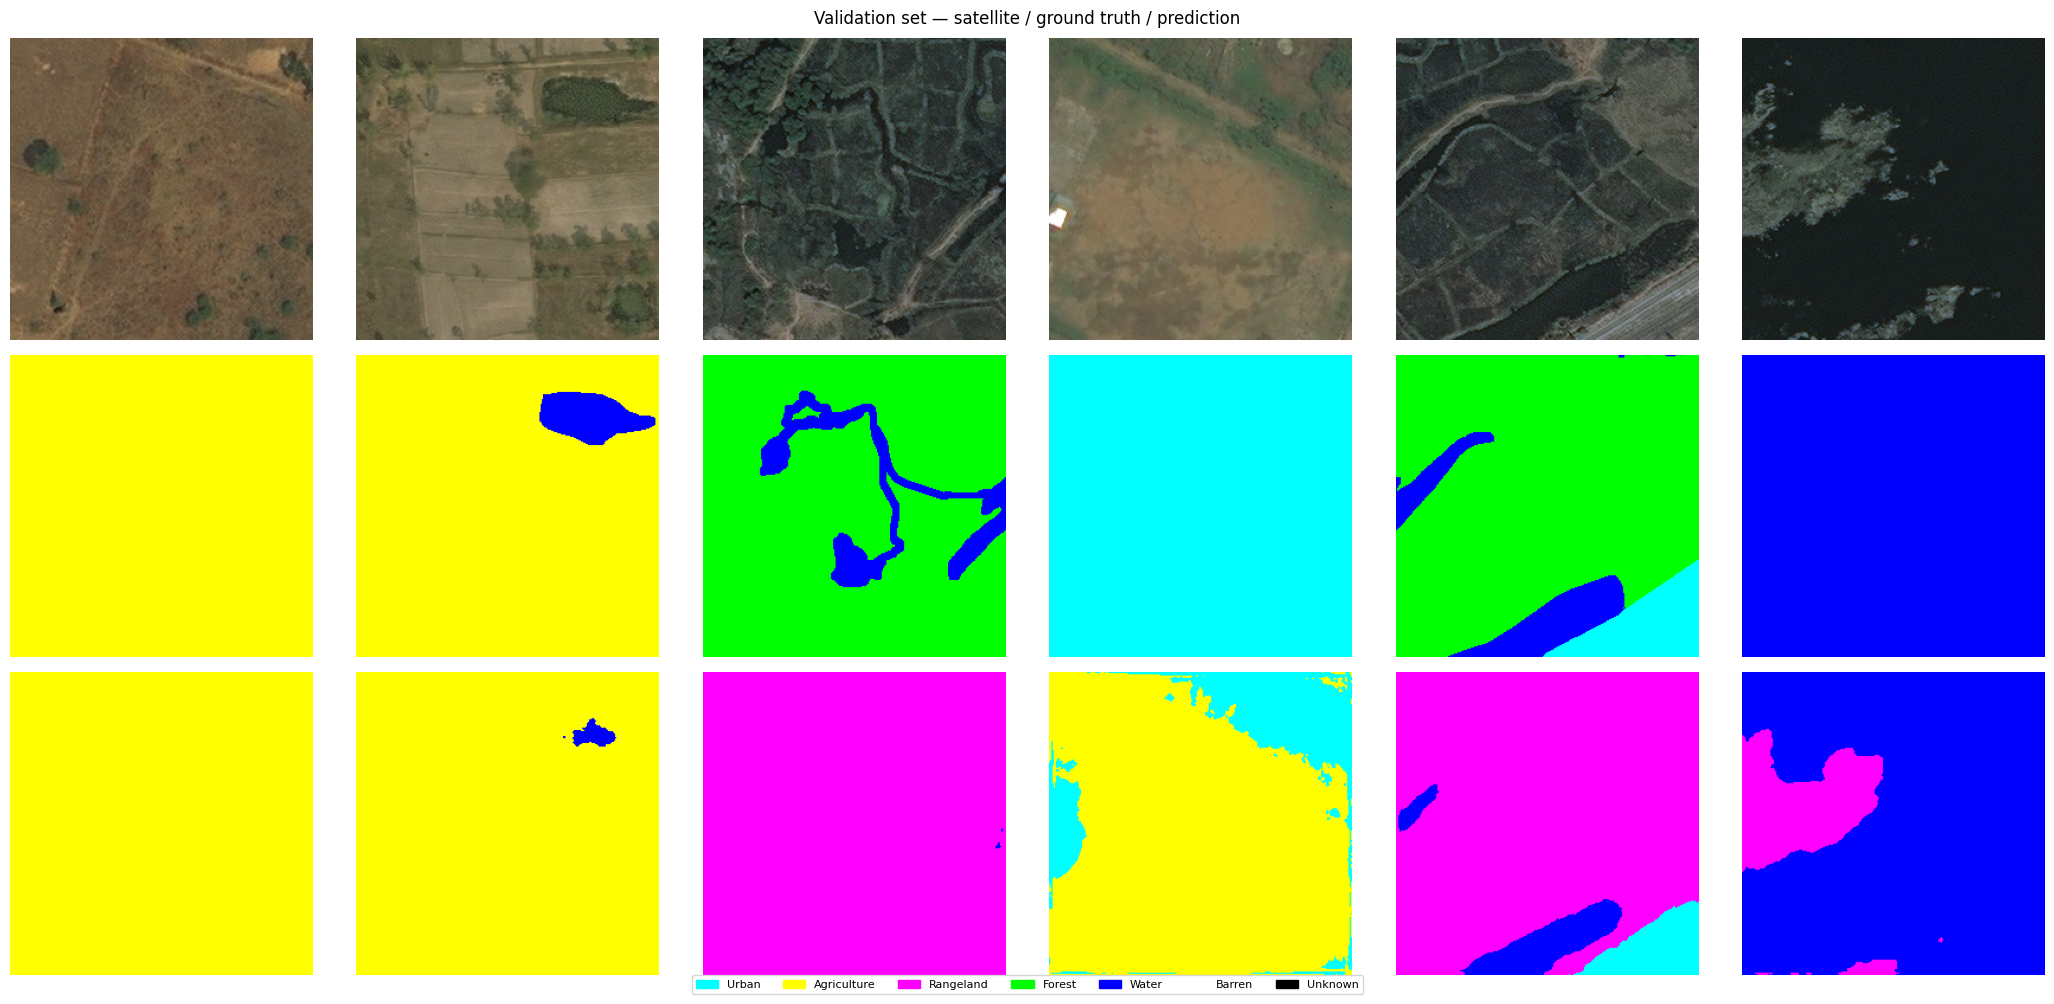

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

LABEL_TO_RGB = np.array(list(CLASS_MAP.values()), dtype=np.uint8)

N_VIS        = 6
N_POOL_BATCH = 40   # sample from 40 spread-out batches → diverse source images

# Step through val_ds at even intervals to avoid tiles from the same image
total_batches = len(val_ds)
step          = max(1, total_batches // N_POOL_BATCH)
target_idxs   = set(range(0, total_batches, step))

pool_imgs, pool_labels = [], []
for i, (imgs, labels) in enumerate(val_ds):
    if i in target_idxs:
        pool_imgs.append(imgs.numpy())
        pool_labels.append(labels.numpy())
    if len(pool_imgs) >= N_POOL_BATCH:
        break

pool_imgs   = np.concatenate(pool_imgs,   axis=0)
pool_labels = np.concatenate(pool_labels, axis=0)

rng       = np.random.default_rng(42)
idxs      = rng.choice(len(pool_imgs), size=N_VIS, replace=False)
sel_imgs  = pool_imgs[idxs]
sel_labels = pool_labels[idxs]

preds       = model.predict(sel_imgs, verbose=0)
pred_labels = np.argmax(preds, axis=-1)

fig, axes = plt.subplots(3, N_VIS, figsize=(N_VIS * 3.5, 10))

for row, label in enumerate(['Satellite', 'Ground Truth', 'Prediction']):
    axes[row, 0].set_ylabel(label, fontsize=10, labelpad=8)

for col in range(N_VIS):
    axes[0, col].imshow(sel_imgs[col])
    axes[0, col].axis('off')

    axes[1, col].imshow(LABEL_TO_RGB[sel_labels[col]])
    axes[1, col].axis('off')

    axes[2, col].imshow(LABEL_TO_RGB[pred_labels[col]])
    axes[2, col].axis('off')

legend_patches = [
    mpatches.Patch(color=np.array(rgb) / 255, label=name)
    for name, rgb in CLASS_MAP.items()
]
fig.legend(handles=legend_patches, loc='lower center', ncol=7,
           fontsize=8, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Validation set — satellite / ground truth / prediction', fontsize=12)
plt.tight_layout()
plt.show()
